# Credit Risk & Borrower Delinquency Analytics

## Objective
Analyze borrower characteristics from a consumer credit dataset (~150,000 borrowers) and identify which characteristics are associated with serious delinquency (90+ days late) within a two-year window.

## Key Business Question
What borrower characteristics are associated with higher delinquency risk?

## Dataset
Source: Kaggle "Give Me Some Credit" (`cs-training.csv`), 150,000 rows, 12 columns. Target variable: `SeriousDlqin2yrs` (1 = borrower was seriously delinquent within 2 years, 0 = not).

## 1. Setup

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Note:** update the path below to wherever `cs-training.csv` is stored on your machine before running.

In [110]:
df=pd.read_csv(r"C:\Users\lenovo\Downloads\cs-training.csv")

## 2. First Look at the Data
Basic shape, structure, and how balanced the target variable is, before doing anything else.

In [111]:
df.head(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [112]:
df.shape

(150000, 12)

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [114]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [115]:
(df.isnull().sum()/ len(df))*100

Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

**Insight:** No missing values at first glance for most columns, but `MonthlyIncome` is missing for ~19.8% of borrowers and `NumberOfDependents` is missing for ~2.6%. That's a real gap to handle, not ignore, since income is one of the most obviously relevant fields for a credit risk question.

In [116]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [117]:
(df["SeriousDlqin2yrs"].value_counts()/ len(df))*100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: count, dtype: float64

**Insight:** The target is heavily imbalanced — only 6.68% of borrowers were seriously delinquent. This matters for the rest of the analysis: the overall average delinquency rate is ~6.7%, so any borrower segment sitting meaningfully above that number is a genuinely higher-risk group, not just noise.

In [118]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 3. Data Quality Investigation
`describe()` above already shows a few numbers that don't make sense for real borrowers (age 0, age 109, values like 96/98 in the past-due columns, debt ratios in the thousands). Before cleaning anything, dig into each one to confirm it's actually a data issue and not a real edge case.

### Age outliers

In [119]:
df[df["age"] == 0].shape

(1, 12)

In [120]:
df[df["age"] == 109].shape

(2, 12)

In [121]:
df[df["age"]==109]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
105790,105791,0,0.109307,109,0,2141.0,NaN,17,0,1,0,NaN
138291,138292,0,0.246529,109,0,318.0,NaN,3,0,0,0,NaN


**Insight:** 1 borrower has age 0 and 2 have age 109 — not plausible values, almost certainly data entry errors. Only 3 rows total, so dropping them costs nothing statistically.

### Revolving utilization outliers

In [122]:
df[df["RevolvingUtilizationOfUnsecuredLines"]>1].shape

(3321, 12)

In [123]:
df[df["RevolvingUtilizationOfUnsecuredLines"]>1]["RevolvingUtilizationOfUnsecuredLines"].describe()

count     3321.000000
mean       259.773362
std       1659.034074
min          1.000059
25%          1.019996
50%          1.074633
75%          1.301096
max      50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [124]:
df.nlargest(10,"RevolvingUtilizationOfUnsecuredLines")

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
85489,85490,0,50708.0,55,0,0.221757,38000.0,7,0,2,0,0.0
31414,31415,0,29110.0,58,0,0.402560,10000.0,7,0,1,0,0.0
16956,16957,0,22198.0,38,0,2312.000000,NaN,5,0,2,0,0.0
149160,149161,0,22000.0,38,0,1.080020,3973.0,7,0,2,0,3.0
149279,149280,0,20514.0,42,0,0.062102,9902.0,1,1,0,0,2.0
117315,117316,0,18300.0,45,0,0.221582,12500.0,5,0,1,0,2.0
21978,21979,0,17441.0,51,1,0.354072,14770.0,14,0,2,0,0.0
124533,124534,0,13930.0,45,0,4902.000000,NaN,4,0,2,0,0.0
72592,72593,0,13498.0,38,0,0.347428,4800.0,6,0,1,0,2.0
71705,71706,0,13400.0,43,0,0.995801,5000.0,11,0,1,0,1.0


**Insight:** Utilization is supposed to be a ratio (credit used / credit limit), so it should realistically sit between 0 and 1. But 3,321 borrowers show values above 1, and some go absurdly high (max ~50,708). These aren't just rounding errors — they need their own bucket rather than being dropped, since a huge value here might itself be a signal (see the early check below).

In [125]:
df["UtilizationGroup"] = np.where(df["RevolvingUtilizationOfUnsecuredLines"]>1 , "High" , "Normal")

In [126]:
df["UtilizationGroup"].value_counts()

UtilizationGroup
Normal    146679
High        3321
Name: count, dtype: int64

In [127]:
df.groupby("UtilizationGroup")["SeriousDlqin2yrs"].mean().reset_index()

,UtilizationGroup,SeriousDlqin2yrs
0,High,0.372478
1,Normal,0.059920


**Insight:** This first rough cut is already a strong signal — borrowers with utilization > 1 have a 37.2% delinquency rate vs 6.0% for the rest. That's over 6x higher. Worth refining into finer buckets later instead of just a High/Normal split.

### Past-due columns: the 96 / 98 placeholder codes

In [128]:
df["NumberOfTime30-59DaysPastDueNotWorse"].describe()

count    150000.000000
mean          0.421033
std           4.192781
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

In [129]:
df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
98       264
6        140
7         54
8         25
9         12
96         5
10         4
12         2
13         1
11         1
Name: count, dtype: int64

**Insight:** The three "days past due" columns all cap out at realistic single/low-double-digit values, except for two specific numbers — 96 and 98 — which show up identically across all three columns (264 rows with 98, 5 rows with 96). That pattern (same row count, same values, across three unrelated columns) is the signature of a placeholder/error code, not a real count of late payments.

In [130]:
df[df["NumberOfTime30-59DaysPastDueNotWorse"]==98]["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
1    143
0    121
Name: count, dtype: int64

In [131]:
df[df["NumberOfTime30-59DaysPastDueNotWorse"]==96]["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
1    4
0    1
Name: count, dtype: int64

**Insight:** Confirms it — the 98-group has a wildly inconsistent delinquency mix (121 non-delinquent vs 143 delinquent) and the 96-group is only 5 rows. Neither looks like a genuine payment history. Treating both as missing (NaN) rather than as real counts.

### DebtRatio outliers

In [132]:
df.nlargest( 10,"DebtRatio")

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,UtilizationGroup
60152,60153,0,0.000000,65,0,329664.0,NaN,9,0,3,0,0.0,Normal
36600,36601,0,0.001782,65,0,326442.0,NaN,6,0,1,0,0.0,Normal
127047,127048,0,0.034290,58,1,307001.0,NaN,16,0,4,0,2.0,Normal
58900,58901,0,0.182640,37,0,220516.0,NaN,8,0,3,0,NaN,Normal
4854,4855,0,0.000000,56,0,168835.0,NaN,10,0,3,0,2.0,Normal
7513,7514,0,0.152293,71,0,110952.0,NaN,9,0,0,0,0.0,Normal
103041,103042,0,0.364845,65,0,106885.0,NaN,8,0,4,0,NaN,Normal
69845,69846,0,0.386451,66,0,101320.0,NaN,12,0,0,0,0.0,Normal
66785,66786,0,1.000000,63,0,61907.0,NaN,13,0,6,0,0.0,Normal
53682,53683,0,1.000000,89,0,61106.5,1.0,2,0,0,0,0.0,Normal


**Insight:** Top DebtRatio values go up to ~330,000 — mathematically that means debt payments are 330,000x monthly income, which isn't realistic. Rather than drop these rows, bucket DebtRatio into ranges later so extreme values land in one group instead of distorting the analysis.

### MonthlyIncome: zeros and missing values

In [133]:
df["MonthlyIncome"].describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [134]:
df[df["MonthlyIncome"] == 0].shape

(1634, 13)

In [135]:
df[df["MonthlyIncome"]==0][["DebtRatio"]].describe()

,DebtRatio
count,1634.000000
mean,1573.567319
std,2818.015889
min,0.000000
25%,96.000000
50%,930.000000
75%,2185.250000
max,60212.000000


In [136]:
df[df["MonthlyIncome"].isnull()][["DebtRatio"]].describe()

,DebtRatio
count,29731.000000
mean,1673.396556
std,4248.372895
min,0.000000
25%,123.000000
50%,1159.000000
75%,2382.000000
max,329664.000000


**Insight:** 1,634 borrowers report exactly ₹0 income, and ~29,731 have income missing entirely. Both groups show unusually high DebtRatio stats compared to the general population, which suggests these aren't random gaps — they may correlate with financial distress or simply inconsistent reporting. Worth checking if the missingness itself is linked to delinquency (below) before deciding how to handle it.

### NumberOfDependents and NumberRealEstateLoansOrLines

In [137]:
df["NumberOfDependents"].describe()

count    146076.000000
mean          0.757222
std           1.115086
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: NumberOfDependents, dtype: float64

In [138]:
df["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

In [139]:
df["NumberRealEstateLoansOrLines"].value_counts()

NumberRealEstateLoansOrLines
0     56188
1     52338
2     31522
3      6300
4      2170
5       689
6       320
7       171
8        93
9        78
10       37
11       23
12       18
13       15
15        7
14        7
17        4
16        4
25        3
18        2
23        2
19        2
20        2
26        1
54        1
21        1
29        1
32        1
Name: count, dtype: int64

**Insight:** Dependents range 0–20 and are heavily skewed toward 0 (most borrowers have none), nothing alarming here besides the missing values already noted. Real estate loans also look reasonable overall — will check further in the segment analysis below.

### Is missing data random, or does it carry a signal?

In [140]:
df["IncomeStatus"]=np.where(df["MonthlyIncome"].isnull() ,"Income Missing" ,"Income Available")

In [141]:
df["IncomeStatus"].value_counts()

IncomeStatus
Income Available    120269
Income Missing       29731
Name: count, dtype: int64

In [142]:
df.groupby("IncomeStatus")["SeriousDlqin2yrs"].mean()

IncomeStatus
Income Available    0.069486
Income Missing      0.056137
Name: SeriousDlqin2yrs, dtype: float64

In [143]:
df.groupby("IncomeStatus")["age"].median()

IncomeStatus
Income Available    51.0
Income Missing      57.0
Name: age, dtype: float64

In [144]:
df["DependentsStatus"]= np.where(df["NumberOfDependents"].isnull() , "Missing" ,"Available")

In [145]:
df["DependentsStatus"].value_counts()

DependentsStatus
Available    146076
Missing        3924
Name: count, dtype: int64

In [146]:
df.groupby("DependentsStatus")["SeriousDlqin2yrs"].mean()

DependentsStatus
Available    0.067410
Missing      0.045617
Name: SeriousDlqin2yrs, dtype: float64

**Insight:** Borrowers with missing income actually have a *slightly lower* delinquency rate (5.6% vs 6.9%) and a higher median age (57 vs 51) — so the missingness looks more like older/retired borrowers not reporting income than a sign of financial trouble. Same pattern for missing dependents (4.6% vs 6.7%). This matters for how the gaps get handled: it's reasonable to keep these rows and flag them as "missing" rather than dropping them, since dropping would bias the dataset toward younger borrowers.

## 4. Data Cleaning
Based on the investigation above: drop the 3 impossible-age rows, and convert the 96/98 placeholder codes in the past-due columns to NaN (leaving them as real numbers would badly distort any average or model).

In [147]:
df_clean = df.copy()

In [148]:
df_clean= df_clean[(df_clean["age"] !=0)& (df_clean["age"] != 109)]

In [149]:
df_clean[df_clean["age"].isin([0, 109])].shape

(0, 15)

In [150]:
df_clean["NumberOfTime30-59DaysPastDueNotWorse"] = df_clean["NumberOfTime30-59DaysPastDueNotWorse"].replace({96: np.nan , 98: np.nan})

In [151]:
df_clean["NumberOfTime30-59DaysPastDueNotWorse"].isin([96,98]).sum()

np.int64(0)

In [152]:
df_clean["NumberOfTime60-89DaysPastDueNotWorse"]=df_clean["NumberOfTime60-89DaysPastDueNotWorse"].replace({96: np.nan , 98: np.nan})

In [153]:
df_clean["NumberOfTime60-89DaysPastDueNotWorse"].isin([96,98]).sum()

np.int64(0)

In [154]:
df_clean["NumberOfTimes90DaysLate"]=df_clean["NumberOfTimes90DaysLate"].replace({96:np.nan , 98: np.nan})

In [155]:
df_clean["NumberOfTimes90DaysLate"].isin([96,98]).sum()

np.int64(0)

In [156]:
df_clean.shape

(149997, 15)

In [157]:
df_clean["MonthlyIncome"].isnull().sum()

np.int64(29729)

In [158]:
df_clean["NumberOfDependents"].isnull().sum()

np.int64(3922)

In [159]:
df_clean[["NumberOfTime30-59DaysPastDueNotWorse","NumberOfTimes90DaysLate","NumberOfTime60-89DaysPastDueNotWorse"]].isnull().sum()

NumberOfTime30-59DaysPastDueNotWorse    269
NumberOfTimes90DaysLate                 269
NumberOfTime60-89DaysPastDueNotWorse    269
dtype: int64

In [160]:
df_clean.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29729
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                       3922
UtilizationGroup                            0
IncomeStatus                                0
DependentsStatus                            0
dtype: int64

**Insight:** After cleaning, 149,997 rows remain. MonthlyIncome and NumberOfDependents keep their missing values on purpose (per the check above), and the three past-due columns now correctly show 269 missing each — the rows that had placeholder codes.

## 5. Delinquency Rate by Borrower Segment
For each variable, the pattern is: bucket it into readable groups, then compare the delinquency rate across groups against the overall baseline of 6.7%.

### Age

In [161]:
df_clean["AgeGroup"] =pd.cut(
    df_clean["age"], 
    bins=[17,29,39,49,59,69,float("inf")] ,
    labels=["18-29","30-39","40-49","50-59","60-69","70+"]
)

In [162]:
df_clean["AgeGroup"].value_counts()

AgeGroup
50-59    35301
40-49    34377
60-69    28905
30-39    23183
70+      19411
18-29     8820
Name: count, dtype: int64

What percentage of borrowers in each age group experienced serious delinquency?

In [163]:
df_clean.groupby("AgeGroup").agg(
    total_borrowers=("SeriousDlqin2yrs" , "count"),
    mean_delinquency=("SeriousDlqin2yrs" , "mean")
).reset_index()

,AgeGroup,total_borrowers,mean_delinquency
0,18-29,8820,0.117347
1,30-39,23183,0.100720
2,40-49,34377,0.083719
3,50-59,35301,0.064531
4,60-69,28905,0.036326
5,70+,19411,0.023183


**Insight:** Clear, steady pattern — delinquency drops as age increases, from 11.7% for 18-29 year-olds down to 2.3% for 70+. Age is one of the strongest and cleanest predictors in this dataset.

### Payment history: 30-59 days past due

In [164]:
df_clean.groupby("NumberOfTime30-59DaysPastDueNotWorse").agg(
    total_borrowers=("SeriousDlqin2yrs" , "count"),
     mean_delinquency=("SeriousDlqin2yrs" , "mean")   
).reset_index()

,NumberOfTime30-59DaysPastDueNotWorse,total_borrowers,mean_delinquency
0,0.0,126016,0.040003
1,1.0,16032,0.150262
2,2.0,4598,0.265115
3,3.0,1754,0.352338
4,4.0,747,0.425703
5,5.0,342,0.450292
6,6.0,140,0.528571
7,7.0,54,0.518519
8,8.0,25,0.320000
9,9.0,12,0.333333


In [165]:
df_clean["PastDue30_59_Group"]=np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"].isnull() , "Unknown" ,
                                        np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"]==0 ,"0"
                                        , np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"]==1,"1"
                                                   , np.where(df_clean["NumberOfTime30-59DaysPastDueNotWorse"]==2 ,"2","3+"))))

In [166]:
df_clean["PastDue30_59_Group"].value_counts()

PastDue30_59_Group
0          126016
1           16032
2            4598
3+           3082
Unknown       269
Name: count, dtype: int64

In [167]:
df_clean.groupby("PastDue30_59_Group").agg(
    total_borrowers=("SeriousDlqin2yrs" , "count"),
     mean_delinquency=("SeriousDlqin2yrs" , "mean")   
).reset_index()

,PastDue30_59_Group,total_borrowers,mean_delinquency
0,0,126016,0.040003
1,1,16032,0.150262
2,2,4598,0.265115
3,3+,3082,0.392602
4,Unknown,269,0.546468


**Insight:** This is the strongest relationship in the whole dataset. Borrowers with zero late payments in this bucket have a 4.0% delinquency rate; even a single late payment jumps that to 15.0%, and 3+ late payments pushes it to 39.3%. Past payment behavior predicts future delinquency far better than any demographic field.

### Payment history: 90+ days late

In [168]:
df_clean.groupby("NumberOfTimes90DaysLate").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    mean_delinquency=("SeriousDlqin2yrs", "mean")
).reset_index()

,NumberOfTimes90DaysLate,total_borrowers,mean_delinquency
0,0.0,141659,0.046266
1,1.0,5243,0.336639
2,2.0,1555,0.499035
3,3.0,667,0.577211
4,4.0,291,0.670103
5,5.0,131,0.633588
6,6.0,80,0.600000
7,7.0,38,0.815789
8,8.0,21,0.714286
9,9.0,19,0.736842


In [169]:
df_clean["PastDue90_Group"]=np.where(df_clean["NumberOfTimes90DaysLate"].isnull() , "Unknown" ,
                                        np.where(df_clean["NumberOfTimes90DaysLate"]==0 ,"0"
                                        , np.where(df_clean["NumberOfTimes90DaysLate"]==1,"1"
                                                   , np.where(df_clean["NumberOfTimes90DaysLate"]==2 ,"2","3+"))))

In [170]:
df_clean["PastDue90_Group"].value_counts()

PastDue90_Group
0          141659
1            5243
2            1555
3+           1271
Unknown       269
Name: count, dtype: int64

In [171]:
df_clean.groupby("PastDue90_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    mean_delinquency=("SeriousDlqin2yrs", "mean")
).reset_index()

,PastDue90_Group,total_borrowers,mean_delinquency
0,0,141659,0.046266
1,1,5243,0.336639
2,2,1555,0.499035
3,3+,1271,0.616837
4,Unknown,269,0.546468


**Insight:** Same pattern, even sharper — 0 late payments of 90+ days = 4.6% delinquency, 1 late payment = 33.7%, 3+ = 61.7%. Borrowers who have ever hit 90 days late are the highest-risk group in this dataset by a wide margin.

### Revolving credit utilization (refined buckets)

In [172]:
df_clean["UtilizationGroup"]= np.where(df_clean["RevolvingUtilizationOfUnsecuredLines"].isnull(),"unknown",
                                       np.where(df_clean["RevolvingUtilizationOfUnsecuredLines"]<=1,"0-1",
                                       np.where(df_clean["RevolvingUtilizationOfUnsecuredLines"]<=2,"1-2","2+")))
                                     

In [173]:
df_clean["UtilizationGroup"].value_counts()

UtilizationGroup
0-1    146676
1-2      2950
2+        371
Name: count, dtype: int64

In [174]:
df_clean.groupby("UtilizationGroup").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    mean_delinquency=("SeriousDlqin2yrs", "mean")
).reset_index()

,UtilizationGroup,total_borrowers,mean_delinquency
0,0-1,146676,0.059921
1,1-2,2950,0.401017
2,2+,371,0.145553


**Insight:** Refining the earlier High/Normal split: utilization 0-1 (the normal range) sits at 6.0% delinquency, 1-2 jumps to 40.1%, but oddly the 2+ group drops back to 14.6%. That drop is worth being honest about — it's likely because the 2+ group is tiny (371 borrowers) and probably includes data errors flagged earlier, not a real reversal in risk.

In [175]:
df_clean[df_clean["RevolvingUtilizationOfUnsecuredLines"]>2]["RevolvingUtilizationOfUnsecuredLines"].describe()

count      371.000000
mean      2316.264874
std       4463.548126
min          2.003992
25%          3.401210
50%        815.000000
75%       2835.500000
max      50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [176]:
df_clean[df_clean["RevolvingUtilizationOfUnsecuredLines"] <= 2].groupby(
    pd.cut(
        df_clean.loc[
            df_clean["RevolvingUtilizationOfUnsecuredLines"] <= 2,
            "RevolvingUtilizationOfUnsecuredLines"
        ],
        bins=[-0.001, 0.25, 0.5, 0.75, 1, 1.5, 2],
        labels=["0-25%", "25-50%", "50-75%", "75-100%", "100-150%", "150-200%"]
    )
)["SeriousDlqin2yrs"].mean()

RevolvingUtilizationOfUnsecuredLines
0-25%       0.021368
25-50%      0.052909
50-75%      0.101279
75-100%     0.182134
100-150%    0.397280
150-200%    0.445415
Name: SeriousDlqin2yrs, dtype: float64

**Insight:** Restricting to the realistic 0-2 range shows a clean, steady climb — 2.1% delinquency at 0-25% utilization up to 44.5% at 150-200%. This is a genuinely strong, well-behaved relationship once the extreme outliers are set aside.

### Debt ratio

In [177]:
df_clean["DebtRatio"].describe()

count    149997.000000
mean        352.995739
std        2037.833467
min           0.000000
25%           0.175073
50%           0.366502
75%           0.868175
max      329664.000000
Name: DebtRatio, dtype: float64

In [178]:
df_clean["DebtRatioGroup"] = pd.cut(
    df_clean["DebtRatio"],
    bins=[-0.001, 0.25, 0.50, 1, 2, float("inf")],
    labels=["0-25%", "25-50%", "50-100%", "100-200%", "200%+"]
)

In [179]:
df_clean["DebtRatioGroup"].value_counts()

DebtRatioGroup
0-25%       52361
25-50%      41346
200%+       31043
50-100%     21155
100-200%     4092
Name: count, dtype: int64

In [180]:
df_clean.groupby("DebtRatioGroup").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

,DebtRatioGroup,total_borrowers,delinquency_rate
0,0-25%,52361,0.059701
1,25-50%,41346,0.061167
2,50-100%,21155,0.098322
3,100-200%,4092,0.131720
4,200%+,31043,0.056438


**Insight:** Less clean than utilization — delinquency rises from 6.0% (0-25%) to a peak of 13.2% (100-200%), but then drops back to 5.6% for the 200%+ group. That drop is a red flag for data quality, not a real effect: the 200%+ bucket is exactly where the extreme, implausible DebtRatio values found earlier live. Flagging this as a limitation rather than reporting it as a genuine finding.

### Monthly income

In [181]:
df_clean["MonthlyIncome"].describe()

count    1.202680e+05
mean     6.670227e+03
std      1.438473e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [182]:
df_clean["IncomeGroup"] = pd.cut(
    df_clean["MonthlyIncome"],
    bins=[-1, 3000, 5000, 8000, 12000, float("inf")],
    labels=["<3K", "3K-5K", "5K-8K", "8K-12K", "12K+"]
)

In [183]:
df_clean["IncomeGroup"].value_counts()

IncomeGroup
5K-8K     32958
3K-5K     30775
<3K       25084
8K-12K    20709
12K+      10742
Name: count, dtype: int64

In [184]:
df_clean.groupby("IncomeGroup").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

,IncomeGroup,total_borrowers,delinquency_rate
0,<3K,25084,0.090775
1,3K-5K,30775,0.082405
2,5K-8K,32958,0.063444
3,8K-12K,20709,0.046550
4,12K+,10742,0.045522


**Insight:** Straightforward and expected — delinquency falls from 9.1% for borrowers earning under 3K to 4.6% for those earning 12K+. Income is a solid, intuitive predictor.

### Number of dependents

In [185]:
df_clean.groupby("NumberOfDependents").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

,NumberOfDependents,total_borrowers,delinquency_rate
0,0.0,86902,0.058629
1,1.0,26316,0.073529
2,2.0,19521,0.081143
3,3.0,9483,0.088263
4,4.0,2862,0.103774
5,5.0,746,0.091153
6,6.0,158,0.151899
7,7.0,51,0.098039
8,8.0,24,0.083333
9,9.0,5,0.000000


**Insight:** Delinquency rises fairly steadily with number of dependents, from 5.9% at 0 dependents to 15.2% at 6 dependents — more financial obligations in the household, more risk. Sample sizes get small at the high end (only 158 borrowers with 6 dependents) so that far end of the trend should be read cautiously.

### Number of open credit lines/loans

In [186]:
df_clean["NumberOfOpenCreditLinesAndLoans"].describe()

count    149997.000000
mean          8.452756
std           5.145932
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

In [187]:
df_clean["OpenCreditGroup"] = pd.cut(
    df_clean["NumberOfOpenCreditLinesAndLoans"],
    bins=[-1, 5, 10, 20, float("inf")],
    labels=["0-5", "6-10", "11-20", "20+"]
)

In [188]:
df_clean.groupby("OpenCreditGroup").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

,OpenCreditGroup,total_borrowers,delinquency_rate
0,0-5,46589,0.084183
1,6-10,60399,0.055382
2,11-20,39029,0.063542
3,20+,3980,0.070101


**Insight:** Not a clean straight-line relationship — borrowers with very few open lines (0-5) actually have the *highest* delinquency (8.4%), while 6-10 lines is the lowest-risk group (5.5%), then risk creeps back up slightly for 11+. This suggests having zero credit history is itself a risk signal, not just "more credit = more risk."

### Real estate loans

In [189]:
df_clean["RealEstateLoanGroup"] = pd.cut(
    df_clean["NumberRealEstateLoansOrLines"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)

In [190]:
df_clean.groupby("RealEstateLoanGroup").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

,RealEstateLoanGroup,total_borrowers,delinquency_rate
0,0,56187,0.083151
1,1,52337,0.052506
2,2,31521,0.055994
3,3,6300,0.066984
4,4+,3652,0.114732


**Insight:** Delinquency is lowest at 1 real estate loan (5.3%) and highest at 4+ (11.5%) — borrowers with no property loans (8.3%) are actually riskier than those with exactly one. Owning a modest, manageable amount of secured debt looks like a stabilizing factor; too much stacks risk back up.

### 60-89 days past due

In [191]:
df_clean["PastDue60_89_Group"] = np.where(
    df_clean["NumberOfTime60-89DaysPastDueNotWorse"].isnull(),
    "Unknown",
    np.where(
        df_clean["NumberOfTime60-89DaysPastDueNotWorse"] == 0,
        "0",
        np.where(
            df_clean["NumberOfTime60-89DaysPastDueNotWorse"] == 1,
            "1",
            np.where(
                df_clean["NumberOfTime60-89DaysPastDueNotWorse"] == 2,
                "2",
                "3+"
            )
        )
    )
)

In [192]:
df_clean["PastDue60_89_Group"].value_counts()

PastDue60_89_Group
0          142393
1            5731
2            1118
3+            486
Unknown       269
Name: count, dtype: int64

In [193]:
df_clean.groupby("PastDue60_89_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

,PastDue60_89_Group,total_borrowers,delinquency_rate
0,0,142393,0.050958
1,1,5731,0.310068
2,2,1118,0.501789
3,3+,486,0.586420
4,Unknown,269,0.546468


## 6. Key Findings

- **Prior payment behavior is the single strongest predictor.** Any history of being late — even once — dramatically raises delinquency risk (30-59 days late: 4.0% → 15.0% after just one occurrence; 90+ days late: 4.6% → 33.7%).
- **Age is a strong, clean predictor.** Delinquency falls steadily from 11.7% (18-29) to 2.3% (70+).
- **Credit utilization matters, but only within a realistic range.** After removing outlier values above 2.0, delinquency climbs smoothly from 2.1% to 44.5% as utilization rises.
- **Income has the expected inverse relationship** — 9.1% delinquency under 3K/month down to 4.6% above 12K/month.
- **Not every variable behaves cleanly.** DebtRatio and the 2+ utilization bucket both show a drop-off at the extreme high end that lines up with the outlier/data-error rows found during the quality check — treated as a data limitation, not a real finding.
- **Missing income and missing dependents were not random** — both groups actually had *lower* delinquency and skewed older, so they were kept in the dataset rather than dropped.

## Limitations
- This is exploratory analysis, not a predictive model — no train/test split, no feature interactions, no evaluation metric.
- Some buckets (6+ dependents, 4+ real estate loans, utilization 2+) have small sample sizes and should be read with caution.

In [194]:
df_clean = df_clean.drop(
    columns=[
        "UtilizationGroup",
        "IncomeStatus",
        "DependentsStatus",
        "DebtRatioGroup",
        "IncomeGroup",
        "OpenCreditGroup",
        "RealEstateLoanGroup"
    ],
    errors="ignore"
)

In [195]:
df_clean = df_clean.rename(columns={
    "AgeGroup": "Age_Group",
    "PastDue30_59_Group": "Late_30_59_Group",
    "PastDue60_89_Group": "Late_60_89_Group",
    "PastDue90_Group": "Late_90Plus_Group"
})

In [196]:
age_analysis = df_clean.groupby("Age_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

In [197]:
age_analysis["delinquency_rate"] = age_analysis["delinquency_rate"] * 100

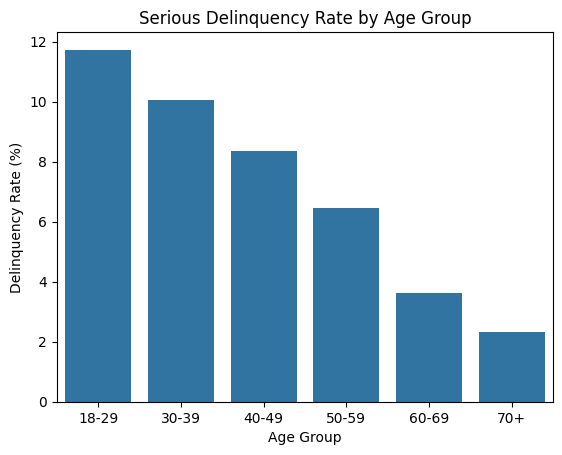

In [198]:
sns.barplot(
    data=age_analysis,
    x="Age_Group",
    y="delinquency_rate"

 ) 
plt.title("Serious Delinquency Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Delinquency Rate (%)")
plt.show()



In [199]:
late30_analysis = df_clean.groupby("Late_30_59_Group").agg(
        total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()


In [200]:
late30_analysis["delinquency_rate"] = late30_analysis["delinquency_rate"]*100

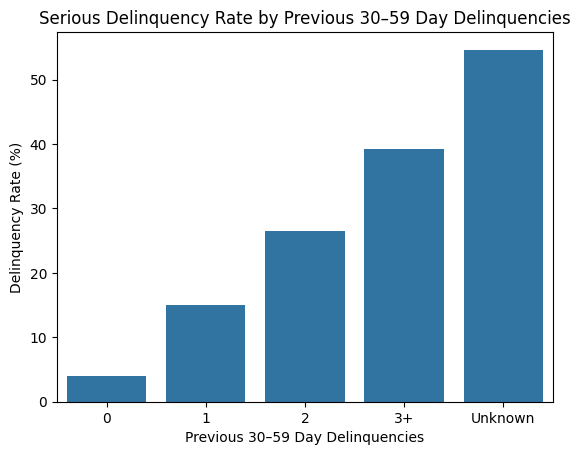

In [201]:
sns.barplot(
    data = late30_analysis ,
    x= "Late_30_59_Group" ,
    y="delinquency_rate"
)
plt.title("Serious Delinquency Rate by Previous 30–59 Day Delinquencies")
plt.xlabel("Previous 30–59 Day Delinquencies")
plt.ylabel("Delinquency Rate (%)")
plt.show()

In [202]:
late60_analysis = df_clean.groupby("Late_60_89_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

In [203]:
late60_analysis["delinquency_rate"] = late60_analysis["delinquency_rate"] * 100

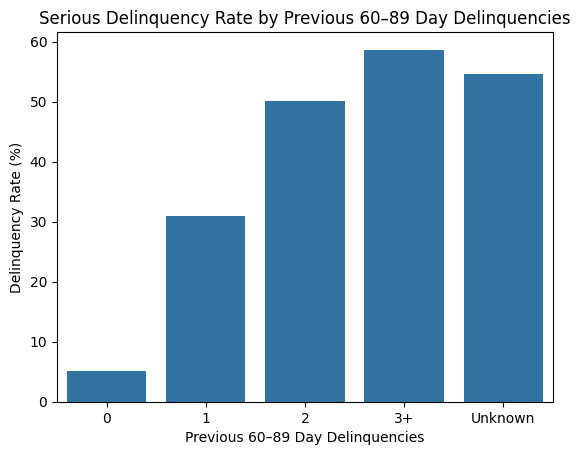

In [204]:
sns.barplot(
    data=late60_analysis,
    x="Late_60_89_Group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Previous 60–89 Day Delinquencies")
plt.xlabel("Previous 60–89 Day Delinquencies")
plt.ylabel("Delinquency Rate (%)")
plt.show()

In [205]:
late90_analysis = df_clean.groupby("Late_90Plus_Group").agg(
    total_borrowers=("SeriousDlqin2yrs", "count"),
    delinquency_rate=("SeriousDlqin2yrs", "mean")
).reset_index()

late90_analysis["delinquency_rate"] *= 100

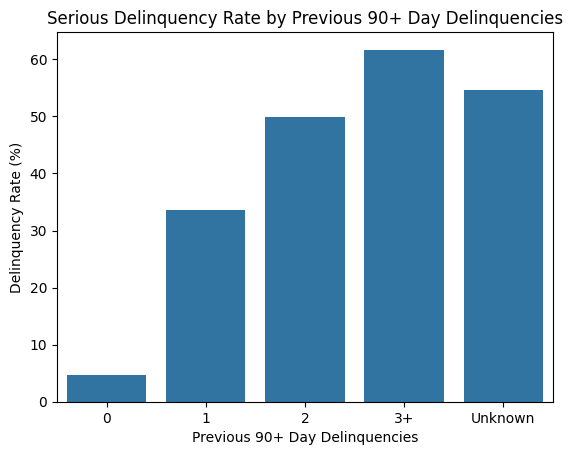

In [206]:
sns.barplot(
    data=late90_analysis,
    x="Late_90Plus_Group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Previous 90+ Day Delinquencies")
plt.xlabel("Previous 90+ Day Delinquencies")
plt.ylabel("Delinquency Rate (%)")
plt.show()

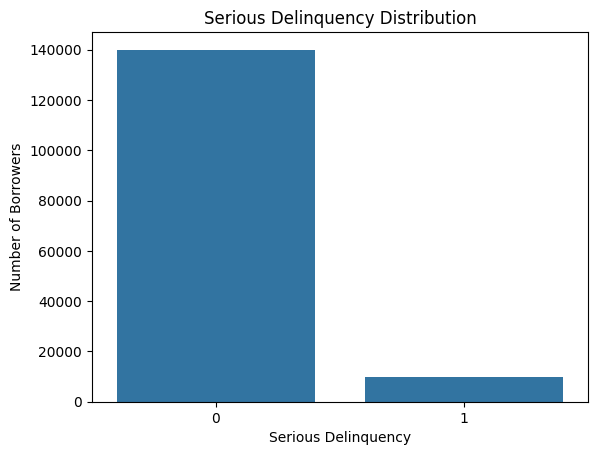

In [212]:
sns.countplot(
    data=df_clean,
    x="SeriousDlqin2yrs"
)

plt.title("Serious Delinquency Distribution")
plt.xlabel("Serious Delinquency")
plt.ylabel("Number of Borrowers")
plt.show()

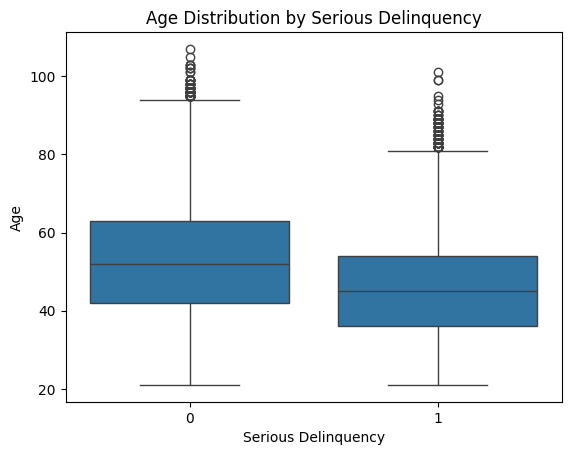

In [213]:
sns.boxplot(
    data=df_clean,
    x="SeriousDlqin2yrs",
    y="age"
)

plt.title("Age Distribution by Serious Delinquency")
plt.xlabel("Serious Delinquency")
plt.ylabel("Age")
plt.show()

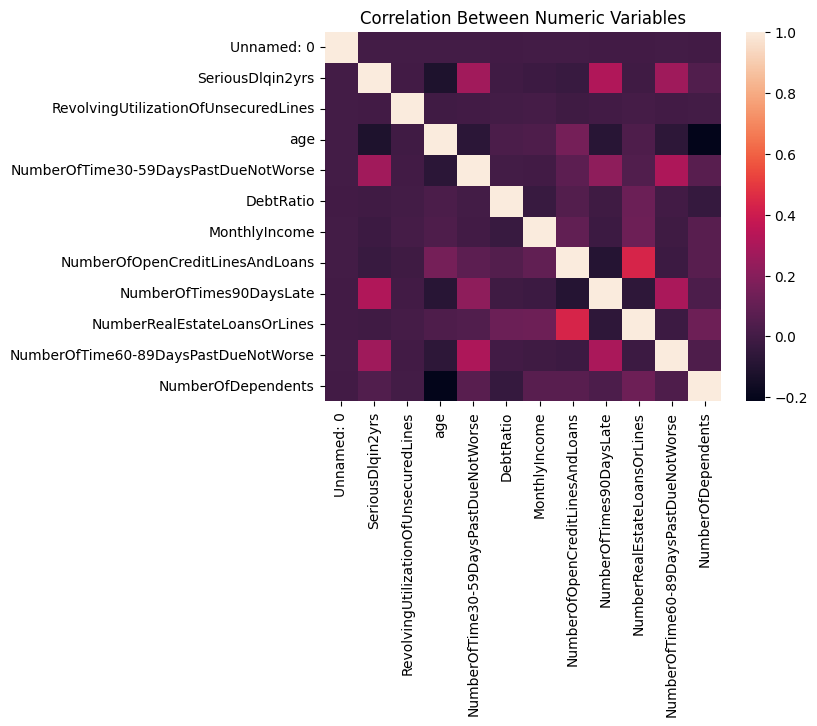

In [214]:
corr = df_clean.select_dtypes(include="number").corr()

sns.heatmap(corr)

plt.title("Correlation Between Numeric Variables")
plt.show()

Key Findings

The overall serious delinquency rate was 6.68%.
Younger borrowers had higher delinquency rates, with 18–29 year olds at 11.73% compared with 2.32% for borrowers aged 70+.
Delinquency increased as the number of previous 30–59 day late payments increased, from 4.00% to 39.26%.
A similar but stronger pattern was seen for previous 60–89 day and 90+ day late payments.
Previous 90+ day delinquency showed the strongest relationship, with the rate increasing from 4.63% to 61.68% for borrowers with 0 versus 3+ previous late payments.

Business Recommendations
Pay more attention to borrowers with previous late payments.
Previous delinquency had the strongest relationship with serious delinquency. Borrowers with repeated late payments could be given closer monitoring or early support.
Use age as a supporting risk factor.
Younger borrowers showed higher delinquency rates in this dataset. Age could be considered along with payment history rather than used on its own.
Focus on early intervention.
Since delinquency rates rise sharply among borrowers with previous late payments, identifying payment problems early could help reduce the chance of more serious delinquency later.
Don't make decisions using one variable alone.
These findings show relationships, not causes. A real lending decision should consider multiple borrower characteristics and additional validation before being used operationally.